# Capstone Project - Image Recognition

Total value: 9 pence (£0.09)


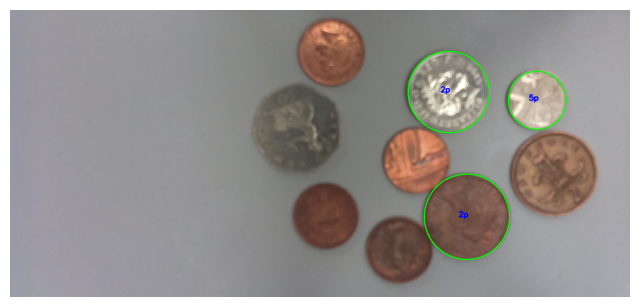

In [14]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('19.1 capstone_coins.png')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Blur to reduce noise
blur = cv2.GaussianBlur(gray, (9, 9), 1.5)

'''
Using OpenCV’s Hough Circle Transform to detect circular objects (coins) in the image.
This is the function that detects the coins as circles. Each of the settings must be set carefully so as to 
increase the accuracy of the detection of circular objects in the picture.
Returns: (x, y, r) for each coin
'''

# Detect circles (coins)
circles = cv2.HoughCircles(
    # blur,
    # cv2.HOUGH_GRADIENT,
    # dp=0.9,
    # minDist=40,
    # param1=50,
    # param2=28,
    # minRadius=60,
    # maxRadius=120

    blur,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=40,
    param1=100,
    param2=30,
    minRadius=20,
    maxRadius=120
)

'''
A dictionary of circle classfied for each unit of British coin within a certain range of radius
'''

# UK coin radius ranges (pixels) → value in pence
coin_sizes = {
    # (20, 30): 1,    # 1p
    # (31, 40): 2,    # 2p
    # (41, 50): 5,    # 5p
    # (51, 60): 10,   # 10p
    # (61, 70): 20,   # 20p
    # (71, 90): 50    # 50p

    (75, 85): 1,    # 1p
    (96, 106): 2,    # 2p
    (70, 74): 5,    # 5p
    (96, 100): 10,   # 10p
    # (61, 70): 20,   # 20p
    # (71, 90): 50    # 50p
}

total_value = 0 #variable for storing all the detected coins value

'''
Outer loop takes the values for one detected coin at a time whilst the inner loop does the actually classification of the coins
based on the radius
'''

if circles is not None: # None means the cv2.HoughCircles function could not find any matching coins
    circles = np.uint16(np.around(circles)) # convert the x, y, r returned by the function into integers

    for x, y, r in circles[0]:
        # Classify coin by radius
        for (min_r, max_r), value in coin_sizes.items():
            if min_r <= r <= max_r: #Checks which size range the detected radius r falls into
                total_value += value #Get value from dictionary if there is a radius match

                # Draw detected coin
                cv2.circle(image, (x, y), r, (0, 255, 0), 2) # x, y is the centre of the coin detected
                cv2.putText(
                    image,
                    f"{value}p",
                    (x - 20, y),
                    cv2.FONT_HERSHEY_SIMPLEX, # Font type
                    0.6,
                    (255, 0, 0),
                    2
                )
                break # Exit the inner loop once a coin is found and move onto the next coin using the outer loop

print(f"Total value: {total_value} pence (£{total_value/100:.2f})")

# Show result
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()


## Notes on the equation of a circle

The equation of a circle is as follows:

$(x - h)^2 + (y - k)^2 = r^2$

With the following variables explained below:

1. $h,k$ is the centre considering that $x-h$ is the horizontal line from the centre and $y-k$ is the vertical line from the centre
2. $r$ is the radius from the centre to the edge of the circle so that $x-h$, $y-k$ and $r$ can be considered as a triangle inside the circle

The equation of a circle is a spin-off of the Pythagorean Theorem: $(a^2+b^2)=c^2$